## Imports

In [18]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import tensorflow as tf

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.optimizers import Adam

print("TensorFlow Version :", tf.__version__)
print("GPU Available :", len(tf.config.list_physical_devices("GPU")))

TensorFlow Version : 2.21.0
GPU Available : 0


## Dataset Paths and Configuration

In [19]:
TRAIN_DIR = "../classification/train"
VALID_DIR = "../classification/val"
TEST_DIR  = "../classification/test"

IMAGE_SIZE = (224,224)
BATCH_SIZE = 32
EPOCHS = 25
LEARNING_RATE = 1e-4
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

## Data Augmentation

In [20]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

## Loading Dataset

In [21]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)
valid_generator = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)
NUM_CLASSES = train_generator.num_classes
print("Classes :", train_generator.class_indices)

Found 1820 images belonging to 26 classes.
Found 390 images belonging to 26 classes.
Found 390 images belonging to 26 classes.
Classes : {'airplane': 0, 'bed': 1, 'bench': 2, 'bicycle': 3, 'bird': 4, 'bottle': 5, 'bowl': 6, 'bus': 7, 'cake': 8, 'car': 9, 'cat': 10, 'chair': 11, 'couch': 12, 'cow': 13, 'cup': 14, 'dog': 15, 'elephant': 16, 'horse': 17, 'motorcycle': 18, 'person': 19, 'pizza': 20, 'potted plant': 21, 'stop sign': 22, 'traffic light': 23, 'train': 24, 'truck': 25}


## Class Weight

In [22]:
labels = train_generator.classes

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0), 7: np.float64(1.0), 8: np.float64(1.0), 9: np.float64(1.0), 10: np.float64(1.0), 11: np.float64(1.0), 12: np.float64(1.0), 13: np.float64(1.0), 14: np.float64(1.0), 15: np.float64(1.0), 16: np.float64(1.0), 17: np.float64(1.0), 18: np.float64(1.0), 19: np.float64(1.0), 20: np.float64(1.0), 21: np.float64(1.0), 22: np.float64(1.0), 23: np.float64(1.0), 24: np.float64(1.0), 25: np.float64(1.0)}


## Pretrained VGG16

In [23]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all pretrained layers
for layer in base_model.layers:
    layer.trainable = False

print(f"Total Layers      : {len(base_model.layers)}")
print(f"Trainable Layers  : {sum([layer.trainable for layer in base_model.layers])}")

Total Layers      : 19
Trainable Layers  : 0


## Classification Head

In [24]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(
    512,
    activation="relu",
    kernel_initializer="he_normal"
)(x)

x = Dropout(0.5)(x)

x = Dense(
    256,
    activation="relu",
    kernel_initializer="he_normal"
)(x)

x = BatchNormalization()(x)

x = Dropout(0.3)(x)

outputs = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=outputs
)

## Summary

In [25]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,32

 Total params: 15,118,426 (57.67 MB)

 Trainable params: 402,202 (1.53 MB)

 Non-trainable params: 14,716,224 (56.14 MB)

## Callbacks

In [26]:
os.makedirs("../models", exist_ok=True)

callbacks = [

    ModelCheckpoint(
        "../models/vgg16_best.keras",
        monitor='val_accuracy',
        mode='max',
        save_best_only=True
    ),

    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-7
    )
]

In [27]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,32

 Total params: 15,118,426 (57.67 MB)

 Trainable params: 402,202 (1.53 MB)

 Non-trainable params: 14,716,224 (56.14 MB)

## Compile 

In [28]:
model.compile(

    optimizer=Adam(
        learning_rate=LEARNING_RATE
    ),

    loss=tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1
    ),

    metrics=[
        "accuracy"
    ]
)

## Callbacks

In [29]:
checkpoint = ModelCheckpoint(
    filepath=os.path.join(
        MODEL_DIR,
        "vgg16_best.keras"
    ),
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)
early_stop = EarlyStopping(

    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)
callbacks = [
    checkpoint,
    early_stop,
    reduce_lr
]

## Train

In [30]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0479 - loss: 4.2148
Epoch 1: val_accuracy improved from None to 0.14359, saving model to ../models\vgg16_best.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.0505 - loss: 4.2049 - val_accuracy: 0.1436 - val_loss: 3.8175 - learning_rate: 1.0000e-04
Epoch 2/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0797 - loss: 3.8742
Epoch 2: val_accuracy improved from 0.14359 to 0.19744, saving model to ../models\vgg16_best.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.0868 - loss: 3.8223 - val_accuracy: 0.1974 - val_loss: 3.2346 - learning_rate: 1.0000e-04
Epoch 3/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0966 - loss: 3.6969
Epoch 3: val_accuracy improved from 0.19744 to 0.28462, saving model to ../models\vgg16_best.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.1110 - loss: 3.6346 - val_accuracy: 0.2846 - val_loss: 2.9840 - learning_rate: 1.0000e-04
Epoch 4/25
57/57 ━━━━━━━━

## Save stage 1 model

In [ ]:
model.save(
    os.path.join(
        MODEL_DIR,
        "vgg16_stage1.keras"
    )
)
print("Stage-1 model saved successfully.")

Stage-1 model saved successfully.


## Plot Training Curves

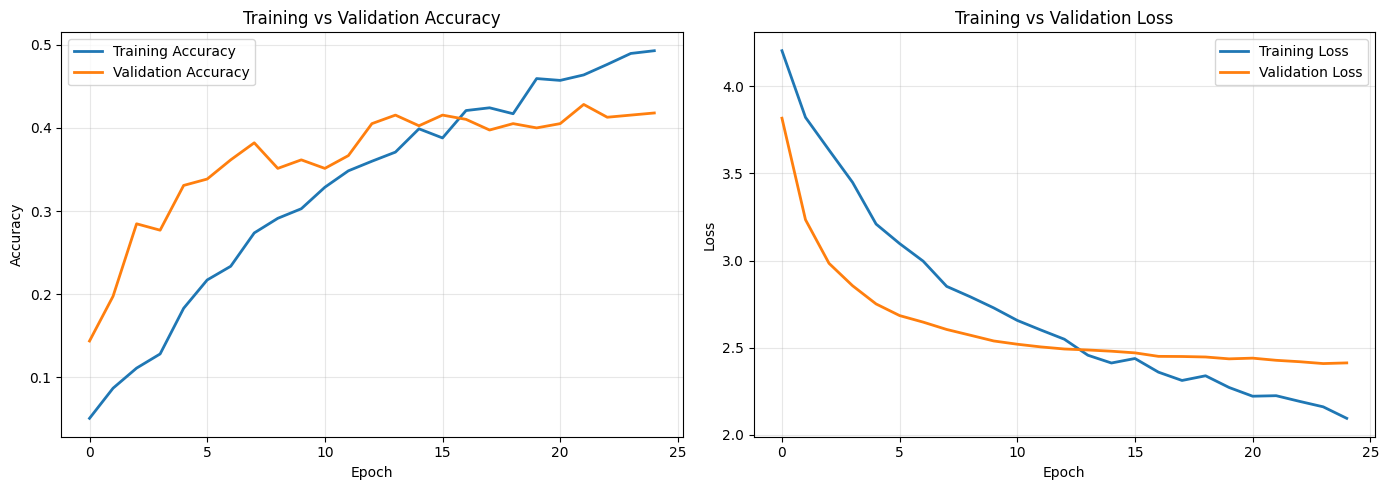

In [ ]:
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy",
    linewidth=2
)
plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
# Loss
plt.subplot(1,2,2)
plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)
plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Unfreeze layers

In [33]:
# Freeze everything first
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze the last 4 convolutional blocks
for layer in base_model.layers[-8:]:
    layer.trainable = True

print("=" * 50)
print("Trainable Layers")
print("=" * 50)

for layer in base_model.layers:
    print(f"{layer.name:30} : {layer.trainable}")

Trainable Layers
input_layer_1                  : False
block1_conv1                   : False
block1_conv2                   : False
block1_pool                    : False
block2_conv1                   : False
block2_conv2                   : False
block2_pool                    : False
block3_conv1                   : False
block3_conv2                   : False
block3_conv3                   : False
block3_pool                    : False
block4_conv1                   : True
block4_conv2                   : True
block4_conv3                   : True
block4_pool                    : True
block5_conv1                   : True
block5_conv2                   : True
block5_conv3                   : True
block5_pool                    : True


## Recompiling for fine tune

In [34]:
model.compile(
    optimizer=Adam(
        learning_rate=1e-5
    ),
    loss=tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1
    ),
    metrics=["accuracy"]
)

## Fine Tune

In [35]:
fine_tune_epochs = 15

history_fine = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=fine_tune_epochs,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4835 - loss: 2.1298
Epoch 1: val_accuracy improved from 0.42821 to 0.44615, saving model to ../models\vgg16_best.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 228s 4s/step - accuracy: 0.4973 - loss: 2.1107 - val_accuracy: 0.4462 - val_loss: 2.4892 - learning_rate: 1.0000e-05
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5219 - loss: 2.0862
Epoch 2: val_accuracy did not improve from 0.44615
57/57 ━━━━━━━━━━━━━━━━━━━━ 234s 4s/step - accuracy: 0.5231 - loss: 2.0574 - val_accuracy: 0.4205 - val_loss: 2.4548 - learning_rate: 1.0000e-05
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5361 - loss: 2.0124
Epoch 3: val_accuracy did not improve from 0.44615
57/57 ━━━━━━━━━━━━━━━━━━━━ 255s 4s/step - accuracy: 0.5258 - loss: 2.0212 - val_accuracy: 0.4205 - val_loss: 2.4044 - learning_rate: 1.0000e-05
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5343 - loss: 1.9641
Epoch 4: val_accuracy improved from

## Save Final Model

In [36]:
final_model_path = os.path.join(
    MODEL_DIR,
    "vgg16_final.keras"
)
model.save(final_model_path)
print("=" * 50)
print("Final model saved successfully!")
print(final_model_path)
print("=" * 50)

Final model saved successfully!
../models\vgg16_final.keras


## Evaluate test dataset

In [37]:
loss, accuracy = model.evaluate(
    test_generator,
    verbose=1
)

print("=" * 50)
print(f"Test Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy*100:.2f}%")
print("=" * 50)

13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.3385 - loss: 2.5109
Test Loss     : 2.5109
Test Accuracy : 33.85%


## Predictions

In [38]:
test_generator.reset()
predictions = model.predict(
    test_generator,
    verbose=1
)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step


## Confusion Matrix

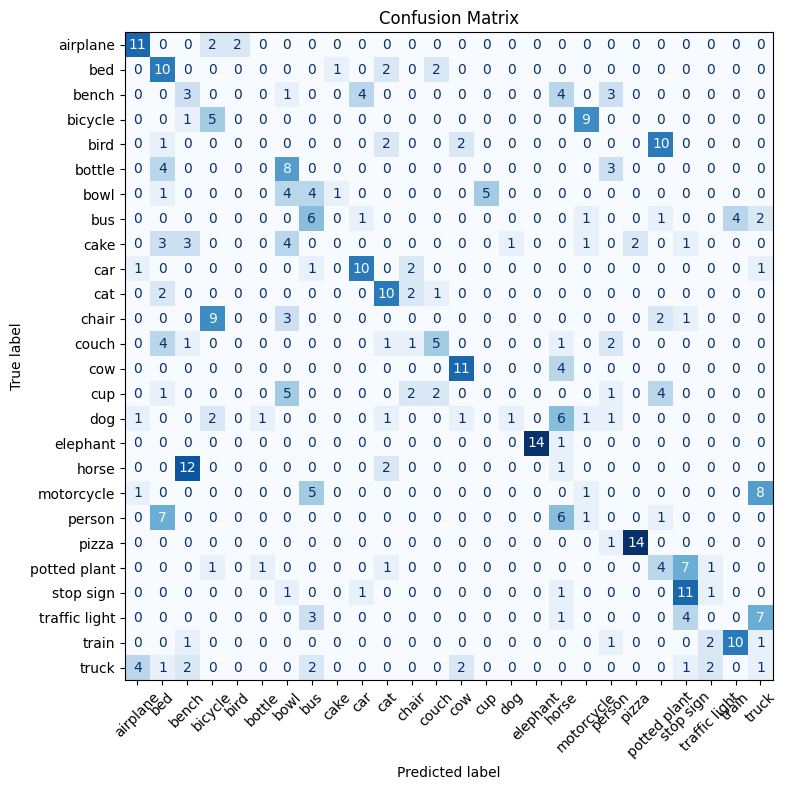

In [39]:
cm = confusion_matrix(
    y_true,
    y_pred
)

fig, ax = plt.subplots(figsize=(10,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    ax=ax,
    xticks_rotation=45,
    colorbar=False
)

plt.title("Confusion Matrix")

plt.tight_layout()

plt.show()

## Classification Report

In [40]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

               precision    recall  f1-score   support

     airplane       0.61      0.73      0.67        15
          bed       0.29      0.67      0.41        15
        bench       0.13      0.20      0.16        15
      bicycle       0.26      0.33      0.29        15
         bird       0.00      0.00      0.00        15
       bottle       0.00      0.00      0.00        15
         bowl       0.15      0.27      0.20        15
          bus       0.29      0.40      0.33        15
         cake       0.00      0.00      0.00        15
          car       0.62      0.67      0.65        15
          cat       0.53      0.67      0.59        15
        chair       0.00      0.00      0.00        15
        couch       0.50      0.33      0.40        15
          cow       0.69      0.73      0.71        15
          cup       0.00      0.00      0.00        15
          dog       0.50      0.07      0.12        15
     elephant       1.00      0.93      0.97        15
        h

## Training History After Fine-Tuning

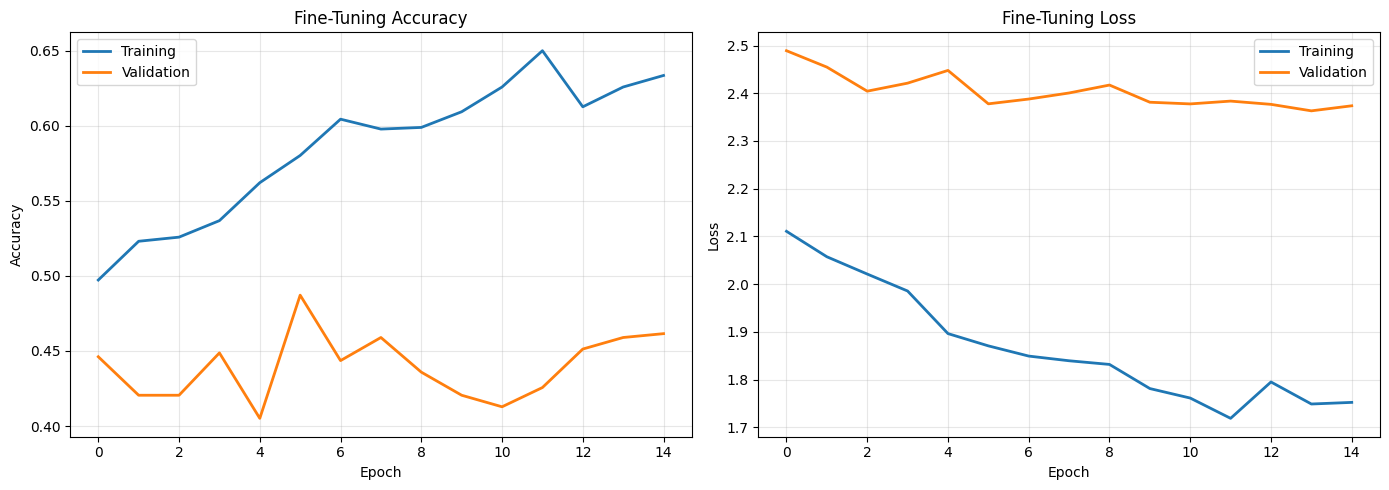

In [41]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(
    history_fine.history["accuracy"],
    linewidth=2,
    label="Training"
)
plt.plot(
    history_fine.history["val_accuracy"],
    linewidth=2,
    label="Validation"
)
plt.title("Fine-Tuning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.subplot(1,2,2)
plt.plot(
    history_fine.history["loss"],
    linewidth=2,
    label="Training"
)
plt.plot(
    history_fine.history["val_loss"],
    linewidth=2,
    label="Validation"
)
plt.title("Fine-Tuning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Final Summary

In [42]:
print("=" * 60)
print("SmartVision V2 - VGG16 Training Complete")
print("=" * 60)

print(f"Number of Classes : {NUM_CLASSES}")
print(f"Image Size        : {IMAGE_SIZE}")
print(f"Batch Size        : {BATCH_SIZE}")

print(f"\nFinal Test Accuracy : {accuracy*100:.2f}%")
print(f"Final Test Loss     : {loss:.4f}")

print("\nSaved Models")

print(f"Best Model  : {os.path.join(MODEL_DIR,'vgg16_best.keras')}")
print(f"Stage-1     : {os.path.join(MODEL_DIR,'vgg16_stage1.keras')}")
print(f"Final Model : {os.path.join(MODEL_DIR,'vgg16_final.keras')}")

print("=" * 60)

SmartVision V2 - VGG16 Training Complete
Number of Classes : 26
Image Size        : (224, 224)
Batch Size        : 32

Final Test Accuracy : 33.85%
Final Test Loss     : 2.5109

Saved Models
Best Model  : ../models\vgg16_best.keras
Stage-1     : ../models\vgg16_stage1.keras
Final Model : ../models\vgg16_final.keras
